#  IEA Global EV Data — Модель ближайших соседей (KNN)

**Задача:** классификация типа силовой установки (`powertrain`: BEV / PHEV / FCEV / EV)  
по признакам: год, показатель (parameter), тип транспорта, численное значение.

**Содержание:**
1. Подготовка данных и разбивка выборки
2. Базовая модель KNN (K = 5)
3. Подбор K через GridSearchCV и RandomizedSearchCV (≥2 стратегии CV)
4. Сравнение метрик базовой и оптимальной моделей


## 0. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    KFold, StratifiedKFold, cross_val_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
RANDOM_STATE = 42


## 1. Загрузка и подготовка данных

In [2]:
df = pd.read_csv('IEA_EV_Data_preprocessed.csv')
print(f"Размер: {df.shape}")
df.head(3)


Размер: (6746, 12)


,region,category_le,mode_le,powertrain_oe,param_EV sales,param_EV sales share,param_EV stock,param_EV stock share,unit_Vehicles,unit_percent,value_scaled,year_scaled
0,Australia,0,1,3.0,0,0,0,1,0,1,-0.092478,-1.793542
1,Australia,0,1,0.0,0,1,0,0,0,1,-0.092478,-1.793542
2,Australia,0,1,0.0,1,0,0,0,1,0,-0.092397,-1.793542


In [3]:
# Целевая переменная: powertrain_oe (0=BEV, 1=PHEV, 2=FCEV, 3=EV)
# Приведём к читаемым меткам для отчётов
label_map = {0: 'BEV', 1: 'PHEV', 2: 'FCEV', 3: 'EV'}

# region — строковый, закодируем LabelEncoder
le_region = LabelEncoder()
df['region_le'] = le_region.fit_transform(df['region'])

# Признаки
feature_cols = (
    ['year_scaled', 'value_scaled', 'mode_le', 'category_le', 'region_le']
    + [c for c in df.columns if c.startswith('param_')]
    + [c for c in df.columns if c.startswith('unit_')]
)

X = df[feature_cols]
y = df['powertrain_oe'].astype(int)

print(f"Признаков: {X.shape[1]}")
print(f"\nРаспределение классов (целевая переменная):")
print(y.map(label_map).value_counts().to_string())


Признаков: 11

Распределение классов (целевая переменная):
powertrain_oe
BEV     2465
EV      2141
PHEV    1351
FCEV     789


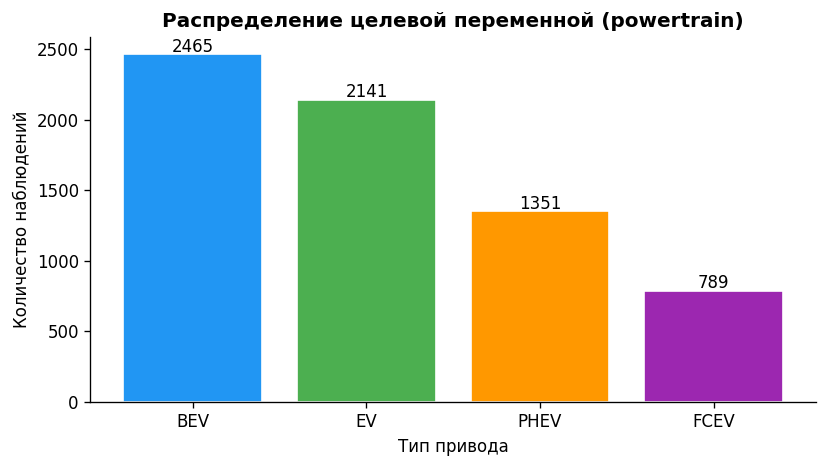

In [4]:
# Визуализация баланса классов
fig, ax = plt.subplots(figsize=(7, 4))
counts = y.map(label_map).value_counts()
ax.bar(counts.index, counts.values,
       color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'], edgecolor='white')
ax.set_xlabel('Тип привода')
ax.set_ylabel('Количество наблюдений')
ax.set_title('Распределение целевой переменной (powertrain)', fontweight='bold')
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()


## 2. Разбивка на обучающую и тестовую выборки

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # сохраняем пропорции классов
)

print(f"Обучающая выборка:  {X_train.shape[0]:,} строк ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Тестовая выборка:   {X_test.shape[0]:,} строк ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nПропорции классов в train:")
print((y_train.map(label_map).value_counts(normalize=True)*100).round(1).to_string())
print(f"\nПропорции классов в test:")
print((y_test.map(label_map).value_counts(normalize=True)*100).round(1).to_string())


Обучающая выборка:  5,396 строк (80.0%)
Тестовая выборка:   1,350 строк (20.0%)

Пропорции классов в train:
powertrain_oe
BEV     36.5
EV      31.7
PHEV    20.0
FCEV    11.7

Пропорции классов в test:
powertrain_oe
BEV     36.5
EV      31.8
PHEV    20.0
FCEV    11.7


## 3. Базовая модель KNN (K = 5)

Обучим `KNeighborsClassifier` с произвольно выбранным гиперпараметром **K = 5**.


In [6]:
K_BASE = 5
knn_base = KNeighborsClassifier(n_neighbors=K_BASE, metric='euclidean')
knn_base.fit(X_train, y_train)

y_pred_base = knn_base.predict(X_test)

acc_base  = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, average='weighted', zero_division=0)
rec_base  = recall_score(y_test, y_pred_base, average='weighted', zero_division=0)
f1_base   = f1_score(y_test, y_pred_base, average='weighted', zero_division=0)

print(f"=== Базовая модель KNN (K={K_BASE}) ===")
print(f"Accuracy : {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall   : {rec_base:.4f}")
print(f"F1-score : {f1_base:.4f}")
print(f"\n{classification_report(y_test, y_pred_base, target_names=list(label_map.values()), zero_division=0)}")


=== Базовая модель KNN (K=5) ===
Accuracy : 0.5837
Precision: 0.5464
Recall   : 0.5837
F1-score : 0.5571

              precision    recall  f1-score   support

         BEV       0.50      0.64      0.57       493
        PHEV       0.19      0.15      0.17       270
        FCEV       0.28      0.11      0.16       158
          EV       0.91      0.96      0.94       429

    accuracy                           0.58      1350
   macro avg       0.47      0.47      0.46      1350
weighted avg       0.55      0.58      0.56      1350



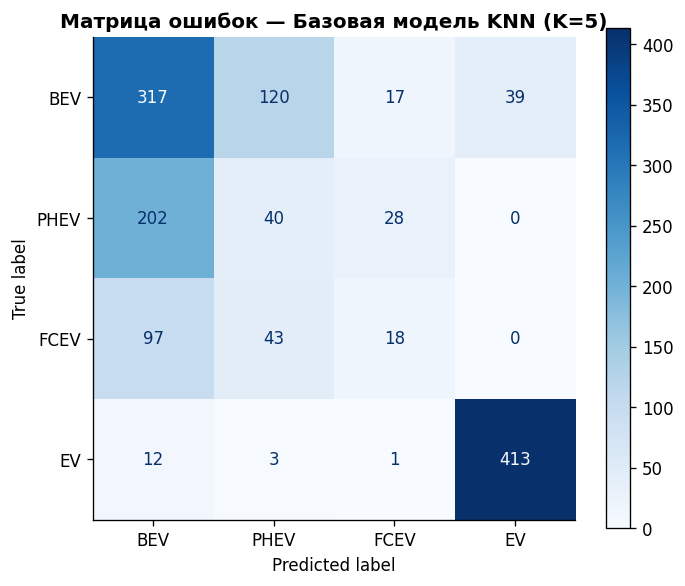

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(cm, display_labels=list(label_map.values()))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Матрица ошибок — Базовая модель KNN (K={K_BASE})', fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Подбор K с GridSearchCV

### 4.1 Стратегия 1 — StratifiedKFold (5 фолдов)

Сохраняет пропорции классов в каждом фолде — оптимально для несбалансированных данных.


In [8]:
param_grid = {'n_neighbors': list(range(1, 31, 2)),   # нечётные K: 1,3,...,29
              'metric': ['euclidean', 'manhattan']}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры (GridSearchCV / StratifiedKFold): {grid_search.best_params_}")
print(f"Лучший CV F1-score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Лучшие параметры (GridSearchCV / StratifiedKFold): {'metric': 'manhattan', 'n_neighbors': 15}
Лучший CV F1-score: 0.5883


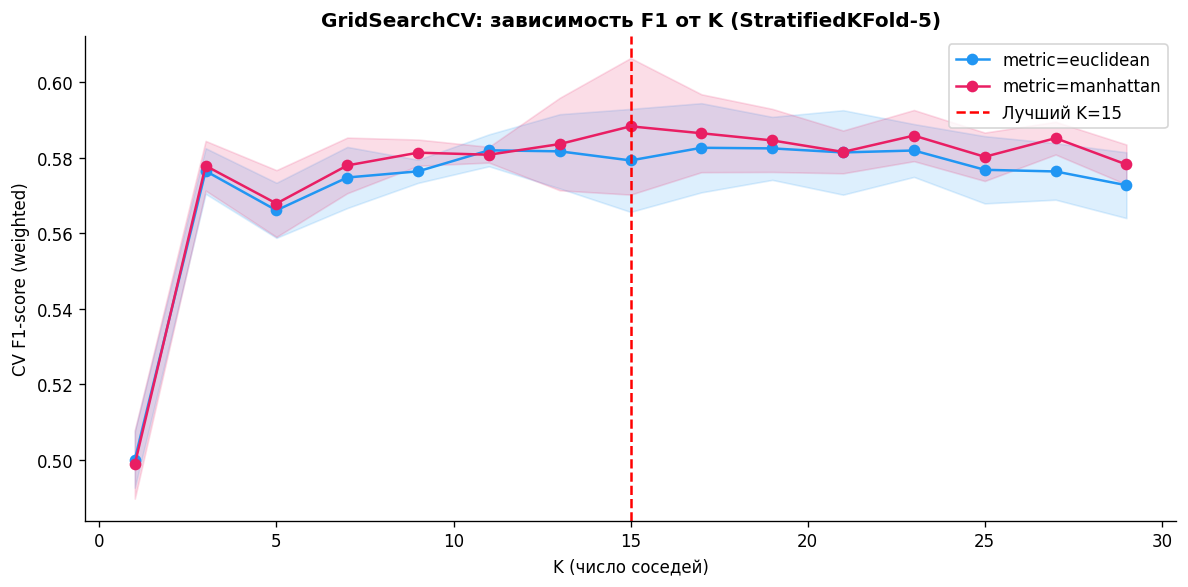

In [10]:
results_gs = pd.DataFrame(grid_search.cv_results_)

# Принудительно приводим к числовым типам
results_gs['param_n_neighbors'] = pd.to_numeric(results_gs['param_n_neighbors'])
results_gs['mean_test_score']   = pd.to_numeric(results_gs['mean_test_score'])
results_gs['std_test_score']    = pd.to_numeric(results_gs['std_test_score'])

fig, ax = plt.subplots(figsize=(10, 5))
for metric_name, color in [('euclidean', '#2196F3'), ('manhattan', '#E91E63')]:
    subset = results_gs[results_gs['param_metric'] == metric_name].sort_values('param_n_neighbors')

    x  = subset['param_n_neighbors'].values.astype(float)
    y  = subset['mean_test_score'].values.astype(float)
    sd = subset['std_test_score'].values.astype(float)

    ax.plot(x, y, marker='o', label=f'metric={metric_name}', color=color)
    ax.fill_between(x, y - sd, y + sd, alpha=0.15, color=color)

best_k = grid_search.best_params_['n_neighbors']
ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Лучший K={best_k}')
ax.set_xlabel('K (число соседей)')
ax.set_ylabel('CV F1-score (weighted)')
ax.set_title('GridSearchCV: зависимость F1 от K (StratifiedKFold-5)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 4.2 Стратегия 2 — KFold (5 фолдов)

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_kf = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
grid_search_kf.fit(X_train, y_train)

print(f"Лучшие параметры (GridSearchCV / KFold): {grid_search_kf.best_params_}")
print(f"Лучший CV F1-score: {grid_search_kf.best_score_:.4f}")


Лучшие параметры (GridSearchCV / KFold): {'metric': 'manhattan', 'n_neighbors': 13}
Лучший CV F1-score: 0.5855


## 5. Подбор K с RandomizedSearchCV

`RandomizedSearchCV` перебирает случайное подмножество комбинаций — эффективнее  
при большом пространстве гиперпараметров. Используем **StratifiedKFold (10 фолдов)**.


In [12]:
from scipy.stats import randint

param_dist = {
    'n_neighbors': randint(1, 51),           # K от 1 до 50
    'metric': ['euclidean', 'manhattan', 'chebyshev'],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]                              # степень Минковского
}

skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

rand_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_dist,
    n_iter=60,
    cv=skf10,
    scoring='f1_weighted',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rand_search.fit(X_train, y_train)

print(f"Лучшие параметры (RandomizedSearchCV): {rand_search.best_params_}")
print(f"Лучший CV F1-score: {rand_search.best_score_:.4f}")


Fitting 10 folds for each of 60 candidates, totalling 600 fits
Лучшие параметры (RandomizedSearchCV): {'metric': 'manhattan', 'n_neighbors': 13, 'p': 1, 'weights': 'uniform'}
Лучший CV F1-score: 0.5804


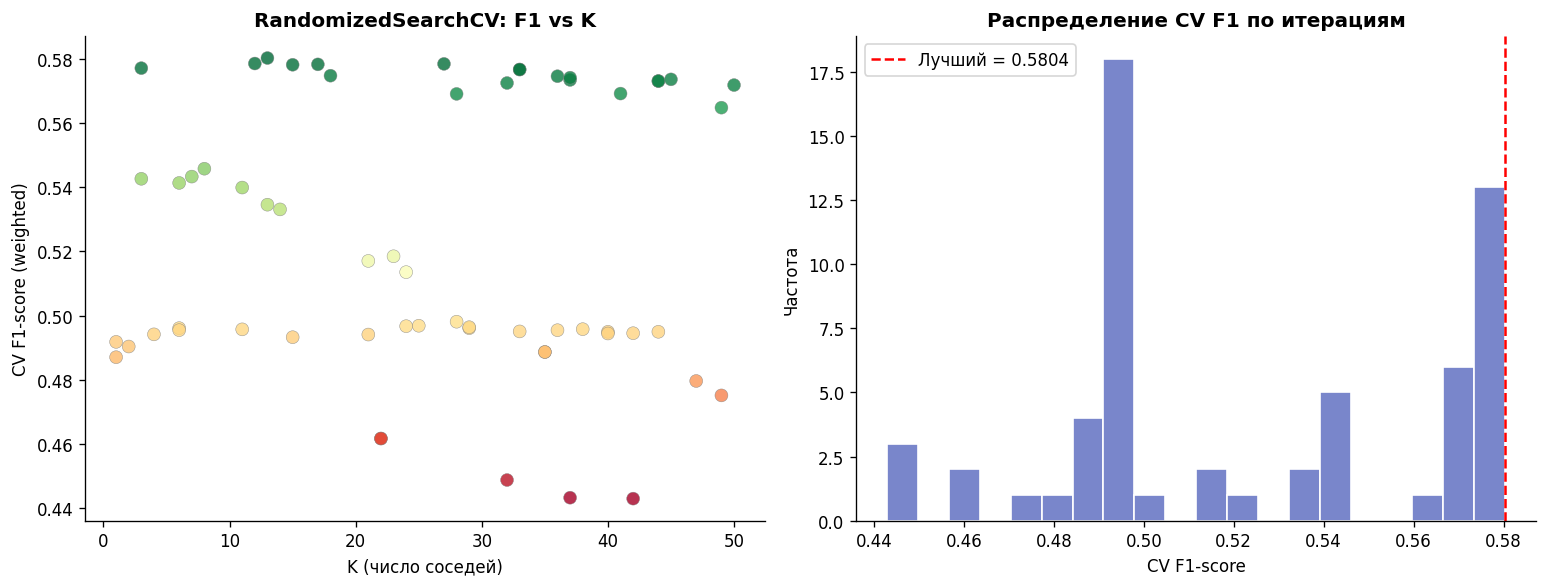

In [13]:
# Распределение CV-score по всем итерациям RandomizedSearch
results_rs = pd.DataFrame(rand_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(results_rs['param_n_neighbors'], results_rs['mean_test_score'],
                c=results_rs['mean_test_score'], cmap='RdYlGn', s=60, alpha=0.8, edgecolors='grey', lw=0.3)
axes[0].set_xlabel('K (число соседей)')
axes[0].set_ylabel('CV F1-score (weighted)')
axes[0].set_title('RandomizedSearchCV: F1 vs K', fontweight='bold')

axes[1].hist(results_rs['mean_test_score'], bins=20, color='#7986CB', edgecolor='white')
axes[1].axvline(rand_search.best_score_, color='red', linestyle='--',
                label=f'Лучший = {rand_search.best_score_:.4f}')
axes[1].set_xlabel('CV F1-score')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение CV F1 по итерациям', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Оценка оптимальной модели

Выберем лучшую модель из GridSearchCV и RandomizedSearchCV по CV F1-score.


In [14]:
best_from_grid = grid_search.best_score_
best_from_rand = rand_search.best_score_

print(f"GridSearchCV  best CV F1: {best_from_grid:.4f}  params: {grid_search.best_params_}")
print(f"RandomizedCV  best CV F1: {best_from_rand:.4f}  params: {rand_search.best_params_}")

best_search = grid_search if best_from_grid >= best_from_rand else rand_search
best_name   = "GridSearchCV" if best_from_grid >= best_from_rand else "RandomizedSearchCV"
print(f"\n>>> Выбрана: {best_name}")


GridSearchCV  best CV F1: 0.5883  params: {'metric': 'manhattan', 'n_neighbors': 15}
RandomizedCV  best CV F1: 0.5804  params: {'metric': 'manhattan', 'n_neighbors': 13, 'p': 1, 'weights': 'uniform'}

>>> Выбрана: GridSearchCV


In [15]:
knn_opt = best_search.best_estimator_
y_pred_opt = knn_opt.predict(X_test)

acc_opt  = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt, average='weighted', zero_division=0)
rec_opt  = recall_score(y_test, y_pred_opt, average='weighted', zero_division=0)
f1_opt   = f1_score(y_test, y_pred_opt, average='weighted', zero_division=0)

print(f"=== Оптимальная модель ({best_name}) ===")
print(f"Параметры: {best_search.best_params_}")
print(f"Accuracy : {acc_opt:.4f}")
print(f"Precision: {prec_opt:.4f}")
print(f"Recall   : {rec_opt:.4f}")
print(f"F1-score : {f1_opt:.4f}")
print(f"\n{classification_report(y_test, y_pred_opt, target_names=list(label_map.values()), zero_division=0)}")


=== Оптимальная модель (GridSearchCV) ===
Параметры: {'metric': 'manhattan', 'n_neighbors': 15}
Accuracy : 0.6044
Precision: 0.5466
Recall   : 0.6044
F1-score : 0.5608

              precision    recall  f1-score   support

         BEV       0.51      0.73      0.60       493
        PHEV       0.22      0.11      0.15       270
        FCEV       0.21      0.08      0.12       158
          EV       0.92      0.96      0.94       429

    accuracy                           0.60      1350
   macro avg       0.46      0.47      0.45      1350
weighted avg       0.55      0.60      0.56      1350



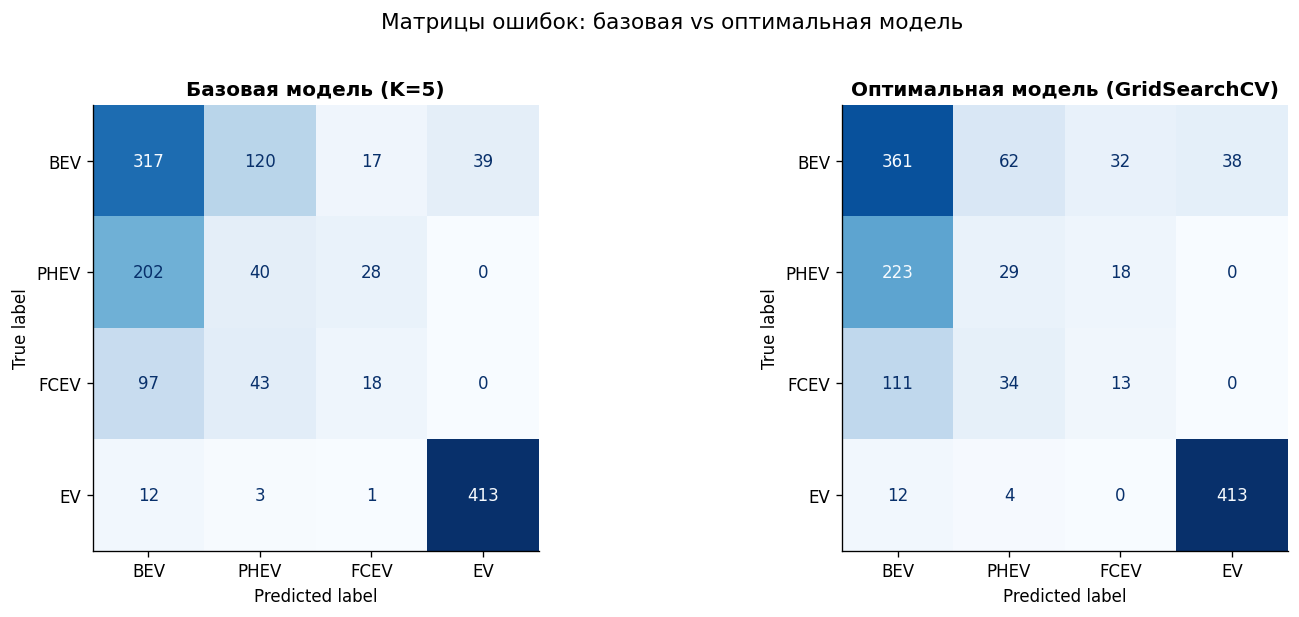

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, title, model_name in zip(
    axes,
    [y_pred_base, y_pred_opt],
    [f'Базовая модель (K={K_BASE})', f'Оптимальная модель ({best_name})'],
    ['base', 'opt']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=list(label_map.values())).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Матрицы ошибок: базовая vs оптимальная модель', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 7. Сравнение метрик базовой и оптимальной моделей

In [17]:
metrics_df = pd.DataFrame({
    'Метрика':   ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 (weighted)'],
    f'Базовая (K={K_BASE})': [acc_base,  prec_base, rec_base,  f1_base],
    f'Оптимальная ({best_name})': [acc_opt, prec_opt,  rec_opt,   f1_opt],
})
metrics_df['Δ (прирост)'] = (
    metrics_df[f'Оптимальная ({best_name})'] - metrics_df[f'Базовая (K={K_BASE})']
)
metrics_df = metrics_df.round(4)
print(metrics_df.to_string(index=False))


             Метрика  Базовая (K=5)  Оптимальная (GridSearchCV)  Δ (прирост)
            Accuracy         0.5837                      0.6044       0.0207
Precision (weighted)         0.5464                      0.5466       0.0001
   Recall (weighted)         0.5837                      0.6044       0.0207
       F1 (weighted)         0.5571                      0.5608       0.0038


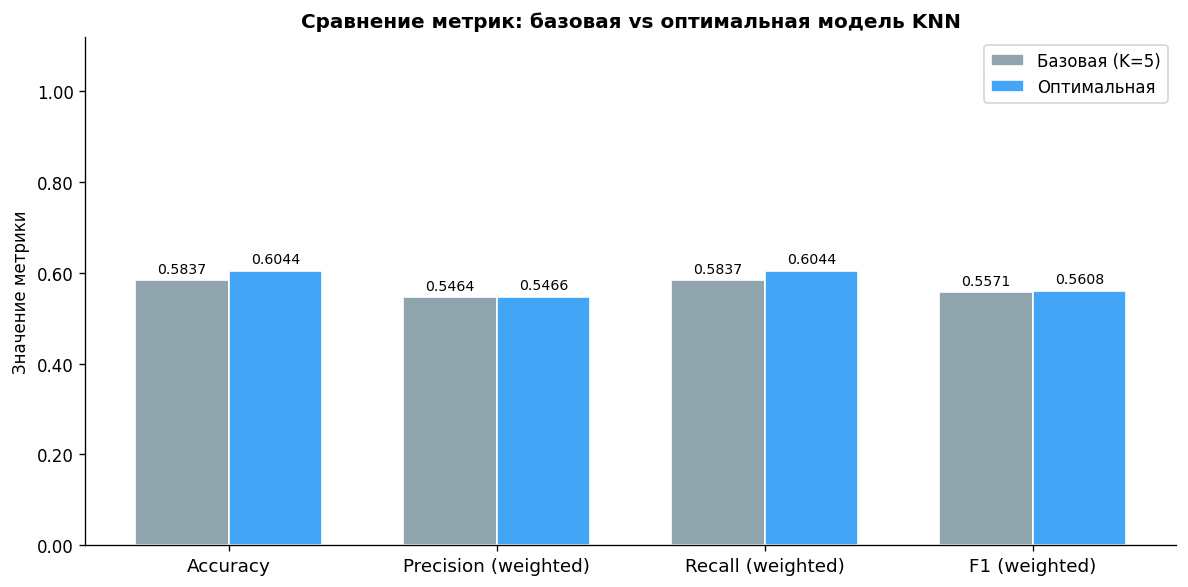

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
metric_names = metrics_df['Метрика'].tolist()
x = np.arange(len(metric_names))
w = 0.35

bars1 = ax.bar(x - w/2, metrics_df.iloc[:, 1], w, label=f'Базовая (K={K_BASE})',
               color='#90A4AE', edgecolor='white')
bars2 = ax.bar(x + w/2, metrics_df.iloc[:, 2], w, label=f'Оптимальная',
               color='#42A5F5', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Значение метрики')
ax.set_ylim(0, 1.12)
ax.set_title('Сравнение метрик: базовая vs оптимальная модель KNN', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()


## 8. Итоги: стратегии кросс-валидации

| Стратегия | Фолдов | Применение | CV F1 |
|-----------|--------|------------|-------|
| **StratifiedKFold** (GridSearchCV) | 5 | Балансирует классы в каждом фолде — лучший выбор при дисбалансе | `grid_search.best_score_` |
| **KFold** (GridSearchCV) | 5 | Случайное разбиение без учёта классов | `grid_search_kf.best_score_` |
| **StratifiedKFold** (RandomizedSearchCV) | 10 | Более детальная оценка с 10 фолдами, случайный поиск по расширенному пространству | `rand_search.best_score_` |

> **Вывод:** `StratifiedKFold` предпочтительнее для многоклассовой задачи, так как гарантирует  
> представленность всех классов в каждом фолде, что даёт более надёжную оценку обобщающей способности модели.


In [19]:
# Итоговая таблица сравнения CV-стратегий
summary = pd.DataFrame({
    'Метод поиска':    ['GridSearchCV',  'GridSearchCV',  'RandomizedSearchCV'],
    'CV стратегия':    ['StratifiedKFold-5', 'KFold-5', 'StratifiedKFold-10'],
    'Лучший K':        [grid_search.best_params_['n_neighbors'],
                        grid_search_kf.best_params_['n_neighbors'],
                        rand_search.best_params_['n_neighbors']],
    'Лучшая метрика':  [grid_search.best_params_['metric'],
                        grid_search_kf.best_params_['metric'],
                        rand_search.best_params_['metric']],
    'CV F1 (weighted)': [round(grid_search.best_score_, 4),
                          round(grid_search_kf.best_score_, 4),
                          round(rand_search.best_score_, 4)],
})
print(summary.to_string(index=False))


      Метод поиска       CV стратегия  Лучший K Лучшая метрика  CV F1 (weighted)
      GridSearchCV  StratifiedKFold-5        15      manhattan            0.5883
      GridSearchCV            KFold-5        13      manhattan            0.5855
RandomizedSearchCV StratifiedKFold-10        13      manhattan            0.5804
